# 08 · BCI Competition IV 2a: CSP and LDA

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Use actual competition motor-imagery data, learn spatial filters inside training folds and evaluate transfer across sessions.

**Data:** BCI Competition IV 2a / BNCI2014-001, subject 1

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

Fixed C3/C4 features are a useful baseline, but information may be spread across the electrode array. Common spatial patterns learns sensor combinations whose variance distinguishes classes. We examine the mathematics before fitting the Competition IV 2a data.

### By the end you should be able to

- Interpret a spatial filter as a weighted sensor sum.
- Derive the binary CSP variance-ratio objective.
- Distinguish decoding filters from sensor patterns.
- Fit CSP and tune its component count inside training folds.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### A spatial filter operates across channels

An epoch $X\in\mathbb R^{C\times T}$ becomes $Z=WX$, where each row of $W$ contains one weight per sensor. The time axis remains intact. A spatial filter can increase a useful contrast by combining channels rather than selecting just one electrode. Its weights depend on the reference, montage, frequency band and calibration data; changing those inputs changes the meaning of the filter.

For two classes, let $\Sigma_1$ and $\Sigma_2$ be class covariance estimates. One formulation of CSP seeks

$$\max_w\frac{w^T\Sigma_1w}{w^T(\Sigma_1+\Sigma_2)w},$$

leading to the generalized eigenproblem

$$\Sigma_1w=\lambda(\Sigma_1+\Sigma_2)w.$$

Large eigenvalues identify directions with relatively more variance in class 1; small eigenvalues identify the opposite contrast. Components from both extremes can be useful. Taking log variance of the projected epoch produces features that a linear classifier can use. CSP does not directly output a class label.

### Read a small example before a large one

If class 1 has covariance `diag(4,1)` and class 2 has `diag(1,4)`, the original sensor directions already separate the variance patterns. The variance-ratio eigenvalues are 0.8 and 0.2. If both covariances are equal, there is no preferred discriminative direction. This example clarifies what the optimization seeks without asking students to interpret a large matrix blindly.

Covariance estimates can be unstable when calibration data are limited or channels are strongly correlated. Regularization moves estimates toward a better-conditioned target. The tradeoff is bias versus variance; it is not a guarantee of higher held-out accuracy. Our pipeline uses regularized covariance and tunes only a small candidate set.

### Binary derivation, four-class experiment

Competition IV 2a contains four movement-imagery classes. The binary derivation provides intuition; MNE's multiclass implementation uses a multiclass covariance decomposition and component ordering, rather than pretending that all non-left trials are a single homogeneous class. Inspect the actual label set and confusion matrix. A score of 0.25 is the balanced-accuracy chance reference for four equally weighted class recalls, not 0.5.

A filter is a weight vector used for discrimination. A sensor pattern describes how a component is expressed across measured sensors. Large decoding weights can suppress correlated noise and should not be read directly as a map of neural activation. The topographies here visualize sensor patterns only. They are not EEG source images and involve no forward or inverse model.

### Why CSP belongs in the pipeline

CSP uses class labels to learn the representation. Fitting it on all trials before cross-validation leaks held-out labels even if the final classifier is refit in each fold. Place CSP and LDA in the same scikit-learn pipeline. Inner grouped folds choose the component count using calibration runs, then one untouched session estimates transfer to a later recording session. Every preprocessing choice that is selected using labels belongs to the same training-only boundary.

### Worked example · a spatial projection

Calculate a sensor difference and a sensor average with one matrix multiplication.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_X=np.array([[1.,2.,3.],[3.,2.,1.]])
demo_W=np.array([[1.,-1.],[.5,.5]])
demo_Z=demo_W@demo_X
print('Projected signals:\n',demo_Z)
assert np.allclose(demo_Z[1],[2,2,2])

Projected signals:
 [[-2.  0.  2.]
 [ 2.  2.  2.]]


**Read the result.** Rows of W combine sensors; they do not convolve over time. Write the matrix dimensions beside each operation.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · solve binary CSP

Use diagonal class covariances and inspect the generalized eigenvalues.

**Before running:** state your prediction and the assumption behind it.

In [3]:
from scipy.linalg import eigh
demo_S1=np.diag([4.,1.]);demo_S2=np.diag([1.,4.])
demo_eig,demo_vec=eigh(demo_S1,demo_S1+demo_S2)
print('Variance ratios:',demo_eig)
assert np.allclose(demo_eig,[.2,.8])

Variance ratios: [0.2 0.8]


**Read the result.** The eigenvectors are normalized under the pooled covariance, not necessarily to unit Euclidean norm.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · no class difference

Repeat the eigenproblem with identical covariance matrices.

**Before running:** state your prediction and the assumption behind it.

In [4]:
demo_same=np.array([[2.,.3],[.3,1.]])
print('Equal-covariance ratios:',eigh(demo_same,2*demo_same)[0])

Equal-covariance ratios: [0.5 0.5]


**Read the result.** Every direction has ratio 0.5. A numerical solver can still return vectors, but those vectors do not imply class information.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · shrink a covariance

Move an ill-conditioned covariance toward a scaled identity and compare condition numbers.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_cov=np.diag([1.,.00001])
demo_target=np.trace(demo_cov)/2*np.eye(2)
for alpha in [0,.1,.5]:
    regularized=(1-alpha)*demo_cov+alpha*demo_target
    print(alpha,np.linalg.cond(regularized))

0 99999.99999999999
0.1 18.996400683870064
0.5 2.999920002399928


**Read the result.** Better conditioning stabilizes matrix operations. Excessive shrinkage can also erase discriminative covariance structure.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Common spatial patterns finds directions with different class variances. For two class covariances $C_1,C_2$, solve $C_1w=\lambda(C_1+C_2)w$. Eigenvectors at opposite ends emphasize either class. A typical feature is $z_j=\log\mathrm{Var}(w_j^TX)$; optional variance normalization changes the definition. MNE supports multiclass CSP with approximate joint diagonalization; the binary eigenproblem explains the intuition but is not the complete four-class algorithm.

CSP is supervised: fitting it on all epochs before cross-validation leaks test labels. Keep CSP and LDA in one scikit-learn pipeline. Spatial **filters** transform sensors into components; spatial **patterns** describe how components project to sensors and are usually more suitable for physiological interpretation.

BNCI2014-001 corresponds to BCI Competition IV dataset 2a: left hand, right hand, feet and tongue imagery. It is fetched by MOABB and represented as MNE epochs. The original competition split and a modern cross-session reanalysis are not identical evaluation claims. Here session 1 is calibration and session 2 is held out; we report a course reanalysis, not an official competition submission.

## Load competition data
Use one participant for a bounded CPU lesson. Expand to all nine participants only after validating the protocol.

The competition loader returns four imagery labels and session/run metadata. One participant keeps the classroom example bounded; the final session remains untouched during selection.

In [6]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30, tmin=0.5, tmax=3.5)
epochs, y, meta = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
X = epochs.get_data(copy=True)
y = np.asarray(y)
sessions = meta.session.astype(str).to_numpy()
groups = (meta.session.astype(str) + '/' + meta.run.astype(str)).to_numpy()
print(pd.crosstab(sessions, y))
assert len(np.unique(sessions)) == 2
train = sessions == sorted(np.unique(sessions))[0]
test = ~train

Choosing from all possible events


<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0   feet  left_hand  right_hand  tongue
row_0                                      
0train    72         72          72      72
1test     72         72          72      72


### Inspect and interpret

Check the number of classes, trials per session and distinct calibration runs. The chance reference for balanced accuracy depends on the four-class label set.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Tune on training runs, test once
Shrinkage stabilizes covariance estimates. Component count is selected only inside the calibration session.

Grid search evaluates a small component-count set using calibration-run groups. Because CSP is inside the pipeline, its supervised spatial filters are relearned in each inner fold. The selected pipeline is refitted on calibration data before the session test.

Training-only choice: {'csp__n_components': 4}
Held-out session balanced accuracy: 0.7847222222222222


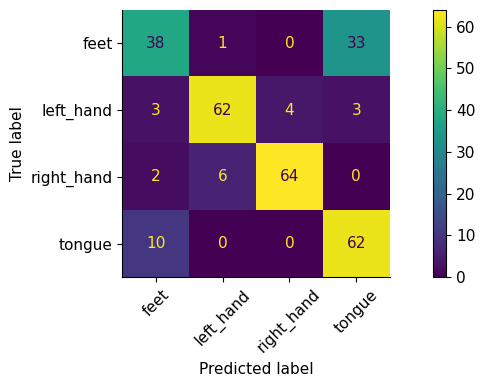

In [7]:
from mne.decoding import CSP
pipeline=make_pipeline(CSP(n_components=4,reg='ledoit_wolf',log=True,norm_trace=False),
                        LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'))
inner=GroupKFold(n_splits=3)
search=GridSearchCV(pipeline,{'csp__n_components':[2,4,6]},cv=inner,
                    scoring='balanced_accuracy',n_jobs=1)
search.fit(X[train],y[train],groups=groups[train])
pred=search.predict(X[test])
print('Training-only choice:',search.best_params_)
print('Held-out session balanced accuracy:',balanced_accuracy_score(y[test],pred))
ConfusionMatrixDisplay.from_predictions(y[test],pred,xticks_rotation=45)
plt.tight_layout(); plt.show()

### Inspect and interpret

Read the selected component count and the full confusion matrix. Separate the inner selection score from the final session score; they describe different stages of the experiment.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Inspect learned patterns
These maps use the calibration-fitted CSP only. They do not establish a causal neural generator.

Plot sensor patterns from the calibration-fitted model. MNE’s component scale and sign conventions are arbitrary, so the maps are interpreted as relative sensor distributions rather than absolute neural activation.

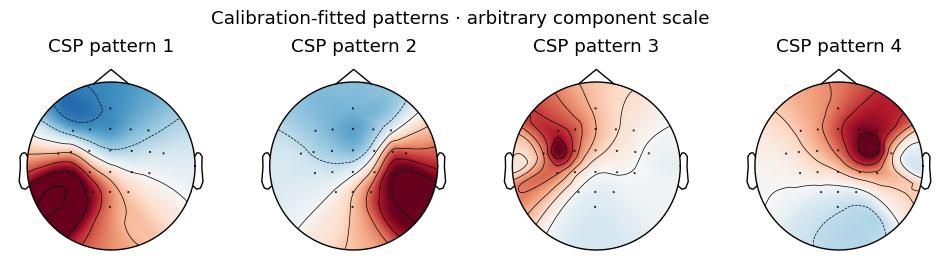

Training epochs: 288 test epochs: 288


In [8]:
csp=search.best_estimator_.named_steps['csp']
fig, axes = plt.subplots(1, csp.n_components, figsize=(3*csp.n_components, 3))
for component, ax in enumerate(np.atleast_1d(axes)):
    mne.viz.plot_topomap(csp.patterns_[component], epochs.info, axes=ax, show=False)
    ax.set_title(f'CSP pattern {component+1}')
fig.suptitle('Calibration-fitted patterns · arbitrary component scale')
plt.show()
print('Training epochs:',int(train.sum()),'test epochs:',int(test.sum()))

### Inspect and interpret

State which channels contribute strongly and whether the map suggests a plausible sensor-level contrast. Do not assign the component to an anatomical brain generator.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Variance-ratio objective

Implement variance_ratio for a vector and two class covariance matrices.

In [9]:
def variance_ratio(w, covariance_a, covariance_b):
    # TODO: evaluate the binary CSP objective.
    return None

In [10]:
answer=variance_ratio(np.array([1.,0.]),demo_S1,demo_S2)
if answer is not None:
    assert np.isclose(answer,.8); print('CSP objective check passed.')
else: print('Exercise pending: implement variance_ratio.')

Exercise pending: implement variance_ratio.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Component inspection

Inspect selected patterns and name the reference, channel set and frequency band. Explain why a pattern is not anatomical localization.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Leakage diagram

Draw the order of fitting CSP, selecting component count and fitting LDA for one inner fold and the final session test.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Baseline comparison

Compare fixed band-power features with CSP using the same session split. Report balanced accuracy and class-specific errors.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Regularization experiment

Try a small regularization grid in inner folds only. Report the chosen value and whether the session-level conclusion changes.

In [14]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Explain why a high calibration score can coexist with weak session transfer, mentioning both model complexity and recording changes.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[Competition 2a via MOABB](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html) · [MNE CSP](https://mne.tools/stable/generated/mne.decoding.CSP.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.